# Alpha Fitting Function Notebook

This notebook defines a function to fit the membrane protein proportion α from a given unknown profile.
You can reuse the function on different unknown profiles by specifying new file paths.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path
import os

In [12]:
####step1 normalize those combined lineprofile.pkl, and can do linear fitting.

In [24]:

def fit_alpha_from_profile(folder, membrane_x_file, membrane_y_file,
                           cyto_x_file, cyto_y_file,
                           unknown_x_file, unknown_y_file,
                           show_plot=True):
    folder = Path(folder)

    x_mem = np.load(folder / membrane_x_file)
    y_mem = np.load(folder / membrane_y_file)

    x_cyto = np.load(folder / cyto_x_file)
    y_cyto = np.load(folder / cyto_y_file)

    x_unknown = np.load(folder / unknown_x_file)
    y_unknown = np.load(folder / unknown_y_file)

    # Unified x-axis (based on membrane profile)
    x_interp = x_mem
    f_mem = interp1d(x_mem, y_mem, kind='linear', fill_value='extrapolate')
    f_cyto = interp1d(x_cyto, y_cyto, kind='linear', fill_value='extrapolate')
    f_unknown = interp1d(x_unknown, y_unknown, kind='linear', fill_value='extrapolate')

    L_mem = f_mem(x_interp)
    L_cyto = f_cyto(x_interp)
    unknown = f_unknown(x_interp)

    # Normalize
    L_mem /= np.max(L_mem)
    L_cyto /= np.max(L_cyto)
    unknown /= np.max(unknown)

    # Fit α using least squares
    alphas = np.linspace(0, 1, 1001)
    errors = [np.mean((a * L_mem + (1 - a) * L_cyto - unknown)**2) for a in alphas]
    optimal_alpha = alphas[np.argmin(errors)]
    best_fit = optimal_alpha * L_mem + (1 - optimal_alpha) * L_cyto

    if show_plot:
        plt.figure(figsize=(8, 4))
        plt.plot(x_interp, unknown, 'k', label='Unknown Profile')
        plt.plot(x_interp, L_mem, '--', label='Membrane Only')
        plt.plot(x_interp, L_cyto, '--', label='Cytoplasm Only')
        plt.plot(x_interp, best_fit, 'r-', label=f'Fitted α = {optimal_alpha:.3f}')
        plt.xlabel("X (µm)")
        plt.ylabel("Normalized Intensity")
        plt.title("Fitting α from Line Profile")
        plt.legend()
        plt.tight_layout()
        ###saving
        save_dir = "../10_fitting_plots"
        os.makedirs(save_dir, exist_ok=True)

        # fig_filename = f"{os.path.basename(folder)}_LSE_fit.png"

        # 提取文件名前缀
        base_name = os.path.basename(unknown_y_file)
        # 去掉后缀部分
        prefix = base_name.replace("_pc_thr_line_profile_y_mean.npy", "")
        # 新文件名
        fig_filename = f"{prefix}_fittingplot.png"
        fig_path = os.path.join(save_dir, fig_filename)
        plt.savefig(fig_path, dpi=300)
        
        plt.show()

    return optimal_alpha


In [ ]:
####converte mscarlet int using GFP/mScar Ratio
###list need to convert: cyto_y_file;unknown_y_file

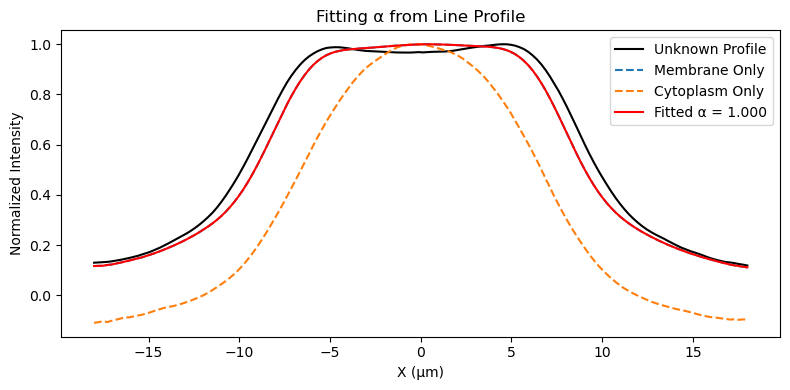

Estimated α: 1.0000


In [25]:
# Example usage (modify these filenames and folder path as needed):
folder = "../8_lineprofile_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="FS460_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="FS460_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


In [15]:
# Example usage (modify these filenames and folder path as needed):
folder = "../8_lineprofile_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="MZ001_100uMIPTG_0ngCTC_combined_pc_thr_line_profile_unnormalized_forfitting_x_ref.npy",
    cyto_y_file="MZ001_100uMIPTG_0ngCTC_combined_pc_thr_line_profile_unnormalized_forfitting_y_mean.npy",
    unknown_x_file="FS463_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="FS463_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: '../8_lineprofile_data/MZ001_100uMIPTG_0ngCTC_combined_pc_thr_line_profile_unnormalized_forfitting_x_ref.npy'

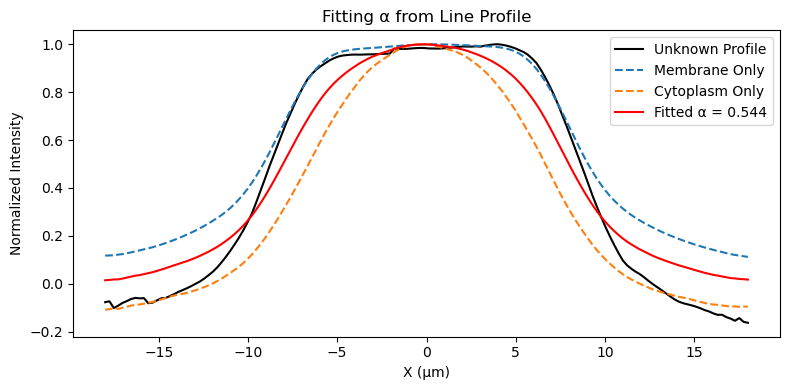

Estimated α: 0.5440


In [26]:
# Example usage (modify these filenames and folder path as needed):
folder = "../8_lineprofile_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="FS463_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="FS463_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


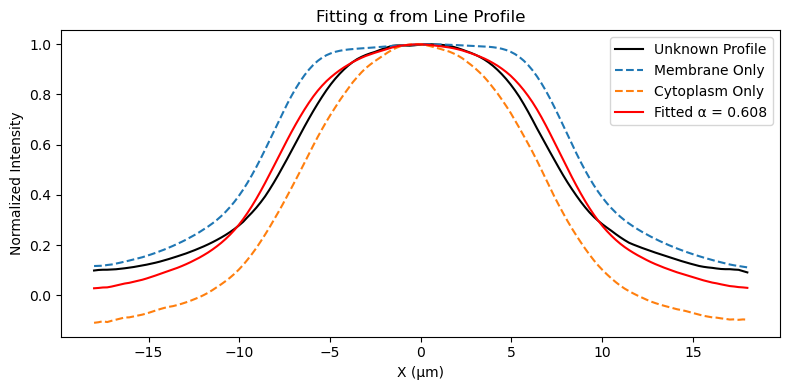

Estimated α: 0.6080


In [27]:
# Example usage (modify these filenames and folder path as needed):
folder = "../8_lineprofile_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="FS073_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="FS073_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


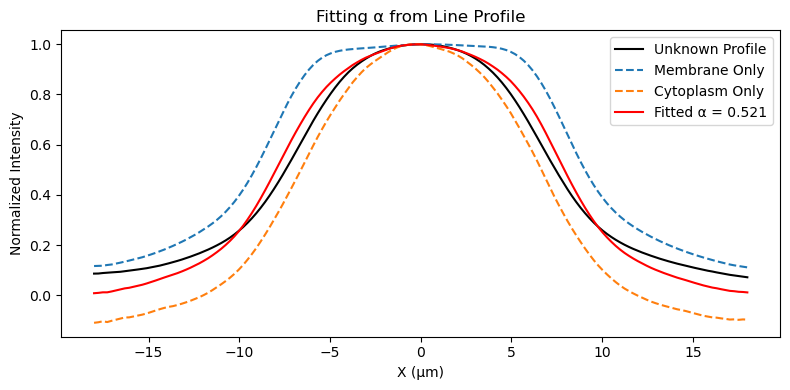

Estimated α: 0.5210


In [28]:
# Example usage (modify these filenames and folder path as needed):
folder = "../8_lineprofile_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="MZ029_100uMIPTG_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="FS073_C2_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="FS073_C2_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


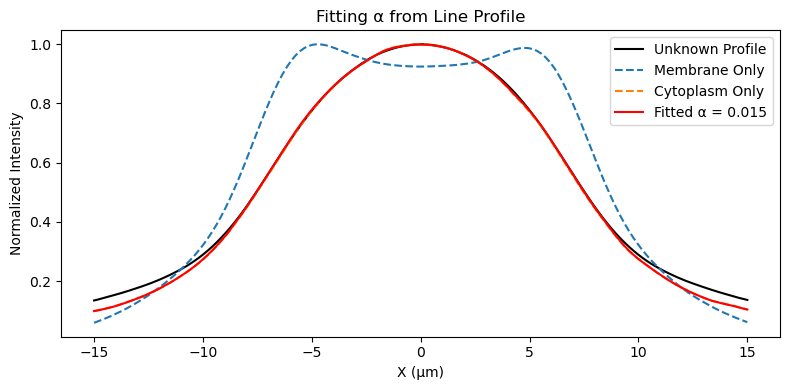

Estimated α: 0.0150


In [11]:
# Example usage (modify these filenames and folder path as needed):
folder = "./test_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="100uMIPTG+1ngCTC_2_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="100uMIPTG+1ngCTC_2_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


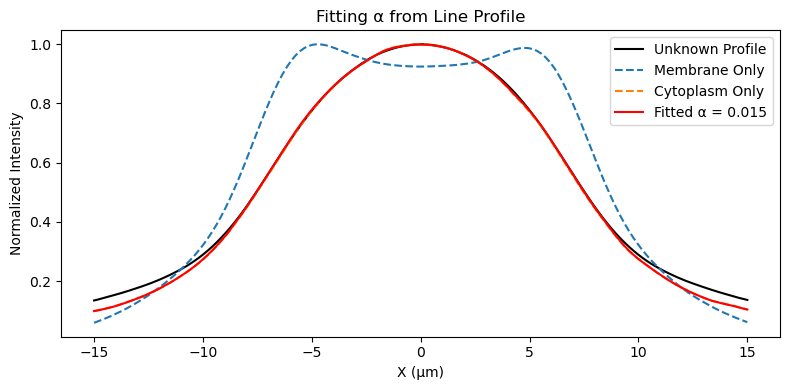

Estimated α: 0.0150


In [ ]:
# Example usage (modify these filenames and folder path as needed):
folder = "./test_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="100uMIPTG+1ngCTC_2_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="100uMIPTG+1ngCTC_2_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


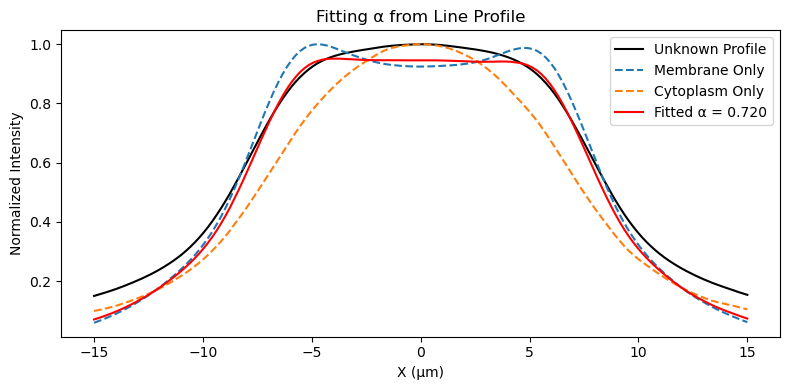

Estimated α: 0.7200


In [18]:
# Example usage (modify these filenames and folder path as needed):
folder = "./test_data"
alpha = fit_alpha_from_profile(
    folder=folder,
    membrane_x_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    membrane_y_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    cyto_x_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_x_ref.npy",
    cyto_y_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    unknown_x_file="100uMIPTG+4ngCTC_2_C1_pc_thr_line_profile_x_ref.npy",
    unknown_y_file="100uMIPTG+4ngCTC_2_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")


In [3]:
######use this!!!! no interp and normalization!!!!!!!
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def fit_alpha_LSE_no_interp(folder, membrane_y_file, cyto_y_file, unknown_y_file, show_plot=True):
    folder = Path(folder)

    y_mem = np.load(folder / membrane_y_file)
    y_cyto = np.load(folder / cyto_y_file)
    y_unknown = np.load(folder / unknown_y_file)

    # 对齐三组数据的最小长度
    min_len = min(len(y_mem), len(y_cyto), len(y_unknown))
    L_mem = y_mem[:min_len]
    L_cyto = y_cyto[:min_len]
    L = y_unknown[:min_len]

    # Least squares 拟合 alpha：使 L ≈ α L_mem + (1 - α) L_cyto
    alphas = np.linspace(0, 1, 1001)
    errors = [np.mean((a * L_mem + (1 - a) * L_cyto - L) ** 2) for a in alphas]
    optimal_alpha = alphas[np.argmin(errors)]
    best_fit = optimal_alpha * L_mem + (1 - optimal_alpha) * L_cyto

    if show_plot:
        plt.figure(figsize=(8, 4))
        plt.plot(L, 'k', label='Unknown Profile')
        plt.plot(L_mem, '--', label='Membrane Only')
        plt.plot(L_cyto, '--', label='Cytoplasm Only')
        plt.plot(best_fit, 'r-', label=f'Fitted α = {optimal_alpha:.3f}')
        plt.xlabel("Index")
        plt.ylabel("Intensity")
        plt.title("Fitting α from Line Profile (No Interpolation or Normalization)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return optimal_alpha


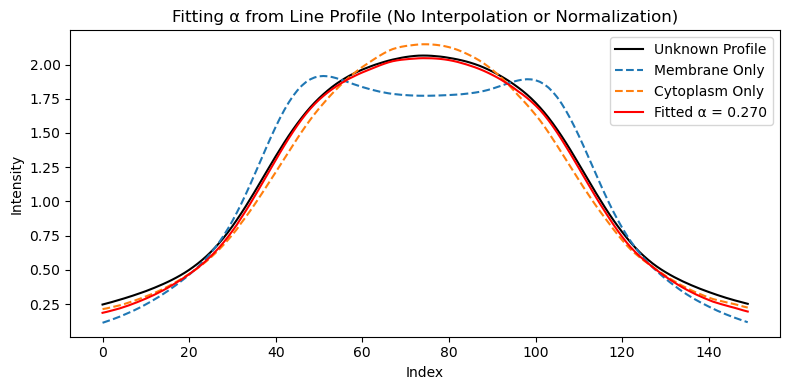

Estimated α: 0.2700


In [5]:
# Example usage (modify these filenames and folder path as needed):
folder = "../test_data"
alpha = fit_alpha_LSE_no_interp(
    folder=folder,
    membrane_y_file="0uMIPTG+4ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    cyto_y_file="100uMIPTG+0ngCTC_1_C1_pc_thr_line_profile_y_mean.npy",
    unknown_y_file="100uMIPTG+2p5ngCTC_2_C1_pc_thr_line_profile_y_mean.npy"
)
print(f"Estimated α: {alpha:.4f}")
